In [14]:
import pandas as pd 
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori , association_rules
import networkx as nx

In [15]:
df=pd.read_csv('Market_Basket_Optimisation.csv', header=None)

In [16]:
def preprocess_transaction(df):
    transactions=[]
    for i in range(0,df.shape[0]):
        transactions.append([str(item) for item in df.iloc[i] if str(item)!='nan'])
    return transactions

transactions = preprocess_transaction(df)

In [17]:
def encoded_transaction(transactions):
    te = TransactionEncoder()
    trans_encoded = te.fit_transform(transactions)
    return pd.DataFrame(trans_encoded , columns = te.columns_)

df_encoded = encoded_transaction(transactions)

In [18]:
def get_rules(min_support , min_confidence):
    frequent_itemsets = apriori(df_encoded ,min_support = min_support, use_colnames = True)
    return association_rules(frequent_itemsets,metric = "confidence",min_threshold=min_confidence),frequent_itemsets

def generate_rules(support_values, confidence_values):
    result =[]
    for support in support_values:
        for confidence in confidence_values:
            rules,_ = get_rules(support,confidence)
            result.append({
                'support':support,
                'confidence':confidence,
                'num_rule':len(rules)
            })
    return pd.DataFrame(result)

In [19]:
support_values = [0.01,0.02,0.03,0.04]
confidence_values = [0.2,0.3,0.4]

result = generate_rules(support_values,confidence_values)
print(result)

    support  confidence  num_rule
0      0.01         0.2       162
1      0.01         0.3        63
2      0.01         0.4        18
3      0.02         0.2        55
4      0.02         0.3        20
5      0.02         0.4         3
6      0.03         0.2        27
7      0.03         0.3         7
8      0.03         0.4         1
9      0.04         0.2         9
10     0.04         0.3         4
11     0.04         0.4         1


In [20]:

rules , frequent_itemsets = get_rules (0.03,0.3)

In [21]:
def visualize(rules):
    plt.scatter(rules['support'],rules['confidence'], marker = 'o',color='red', label = 'SUPPORT VS CONFIDENCE')
    plt.xlabel('Support')
    plt.ylabel('confidence')
    plt.title("support vs confidence")
    plt.grid(True)
    plt.show()
    plt.scatter(rules['confidence'],rules['lift'], marker = 'o',color='blue', label = 'confidence vs lift')
    plt.xlabel('confidence')
    plt.ylabel('lift')
    plt.title("confidence vs lift")
    plt.grid(True)
    plt.show()


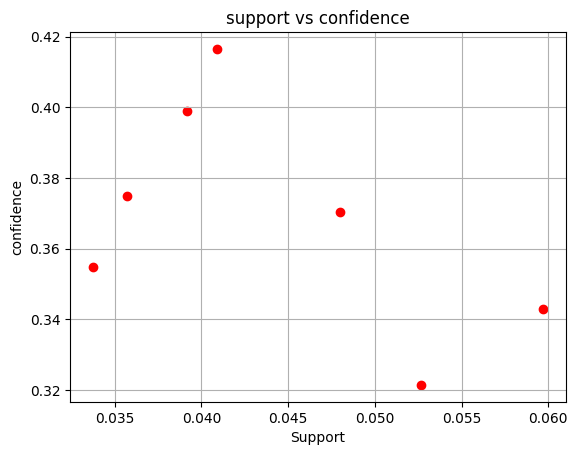

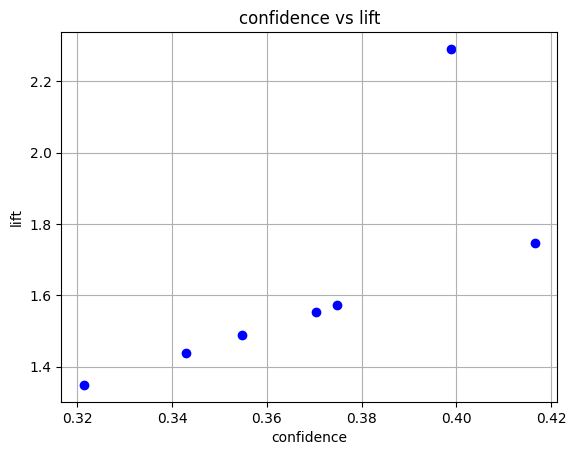

In [22]:
visualize(rules)

In [23]:
def create_graph(rules):
    G = nx.DiGraph()
    for _, rule in rules.iterrows():
        antecedent = ', '.join(list(rule['antecedents']))
        consequent = ', '.join(list(rule['consequents']))
        G.add_edge(antecedent, consequent, weight=rule['lift'])
    
    return G

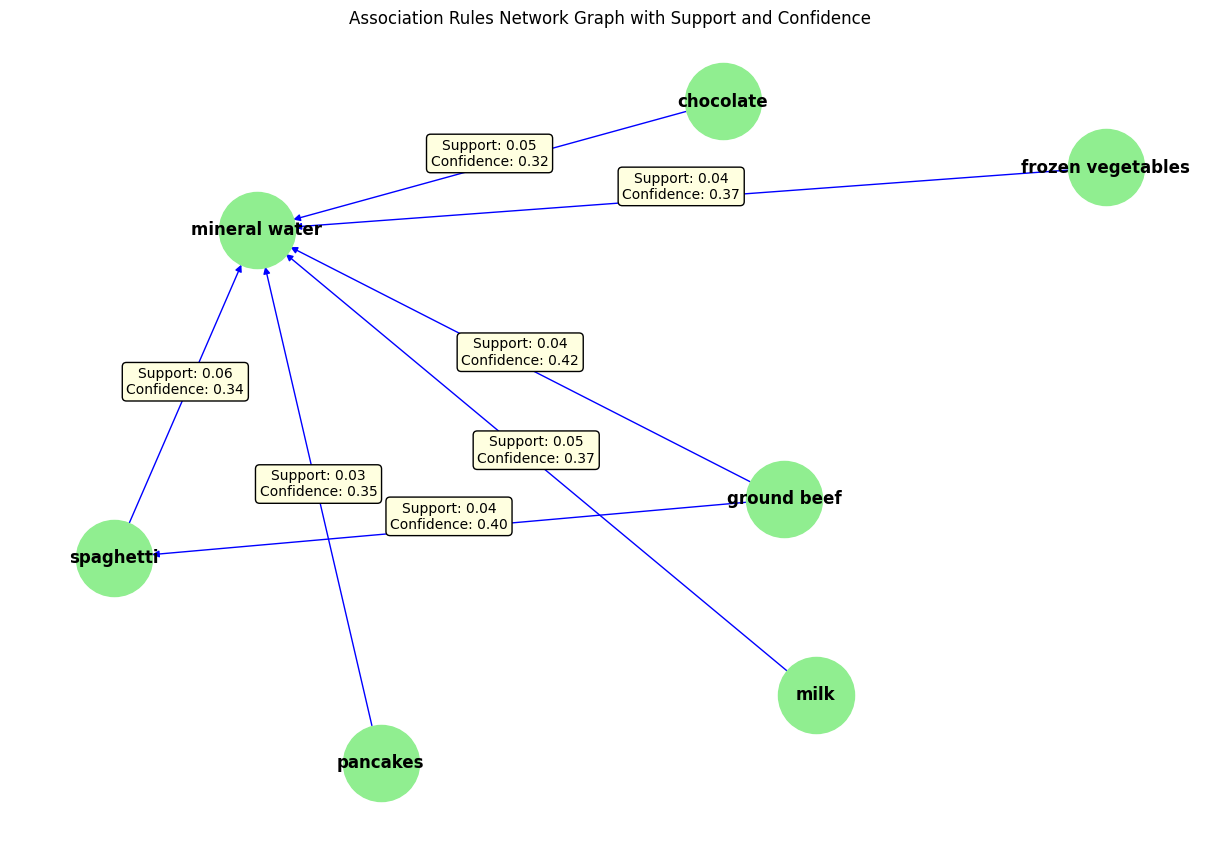

           antecedents      consequents  antecedent support  \
0          (chocolate)  (mineral water)            0.163845   
1  (frozen vegetables)  (mineral water)            0.095321   
2        (ground beef)  (mineral water)            0.098254   
3        (ground beef)      (spaghetti)            0.098254   
4               (milk)  (mineral water)            0.129583   
5           (pancakes)  (mineral water)            0.095054   
6          (spaghetti)  (mineral water)            0.174110   

   consequent support   support  confidence      lift  leverage  conviction  \
0            0.238368  0.052660    0.321400  1.348332  0.013604    1.122357   
1            0.238368  0.035729    0.374825  1.572463  0.013007    1.218270   
2            0.238368  0.040928    0.416554  1.747522  0.017507    1.305401   
3            0.174110  0.039195    0.398915  2.291162  0.022088    1.373997   
4            0.238368  0.047994    0.370370  1.553774  0.017105    1.209650   
5            0.238368

In [24]:
# Step 5: Visualize the graph with support and confidence annotations
def visualize_graph(G, rules, save_as_image=False):
    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G, k=2)

    # Draw the graph
    nx.draw(G, pos, with_labels=True, node_size=3000, node_color='lightgreen', font_size=12, font_weight='bold', edge_color='blue')

    # Annotate edges with support and confidence
    for _, rule in rules.iterrows():
        antecedent = ', '.join(list(rule['antecedents']))
        consequent = ', '.join(list(rule['consequents']))
        support = rule['support']
        confidence = rule['confidence']
        
        # Get positions of nodes
        x1, y1 = pos[antecedent]
        x2, y2 = pos[consequent]
        mid_x = (x1 + x2) / 2
        mid_y = (y1 + y2) / 2

        plt.annotate(f'Support: {support:.2f}\nConfidence: {confidence:.2f}', 
                     xy=(mid_x, mid_y), 
                     fontsize=10, 
                     ha='center', 
                     bbox=dict(boxstyle="round,pad=0.3", edgecolor='black', facecolor='lightyellow'))

    plt.title('Association Rules Network Graph with Support and Confidence')
    plt.show()

# Create and visualize the graph
G = create_graph(rules)
visualize_graph(G, rules, save_as_image=True)

print(rules)